# Notebook 3 of 3 -- Project Walkthrough, Part 2: Applying the Three Papers to Notebook 2's Corpus

> **Trace**
> - **Paper:** ALL -- the table below maps each section to its paper (P2 in `## 2`, P3 in `## 3`, P1 in `## 4` and `## 5`)
> - **Result and query:** research constraints re-read from the NotebookLM history -- `q4`, `q5`, `q7`, `q10`, `q2`, `q12`
> - **Status:** CONVENTION REUSED (P2's protocol, P3's Table 2 convention); QUOTED (CHES definitions)

This is the third notebook in a three-part portfolio series built around an Upwork job posting
("AI Alignment / Post-Training Researcher"; job text in `research/job-posting.md`). Notebook 2
replicated a plausible version of the client's human data-collection framework (reasoning traces,
rubrics, preference pairs) on a synthetic corpus with known latent truth, plus an
**accuracy-centric QA baseline** -- correctness rates, inter-annotator agreement, rubric pairwise
accuracy, verifier agreement -- all with honest confidence intervals.

**Important framing, same as Notebook 2:** this is a *draft scaffold*, not a finished audit and not
a claim of prior production experience at any client's scale. Every threshold and design choice
below is left open for a human collaborator to reshape. Nothing here is tuned-until-it-looks-good:
real-model results are reported as measured, including where an effect is small or a trend is noisy.

**What this notebook adds -- the three papers, applied to Notebook 2's pipeline:**

| Section | Paper | Question it answers here |
|---|---|---|
| `## 2` | *What Makes a Reward Model a Good Teacher?* (Razin et al., NeurIPS 2025, arXiv:2503.15477) | Which tasks have on-policy reward variance too low to give GRPO/policy-gradient any signal, even before training starts? |
| `## 3` | *Chasing the Tail* (Zhang et al., ICLR 2026, arXiv:2509.21500) | Does the client's rubric verifier stay accurate among the *best* responses, where it matters most for RL, not just on average? |
| `## 4`, `## 5` | *Unintentional Unalignment* (Razin et al., ICLR 2025, arXiv:2410.08847) | Do the near-duplicate preference pairs Notebook 2 built actually show higher CHES on a real model, and does a real (if tiny) DPO step displace them more? |

**Research constraints this notebook honours** (re-read from the NotebookLM history via
`research/reread.sh`; slugs are `nlm/responses/alignsig-qN.json`; the full contract is
`research/notebook-research-context.md`, lookup-only):
- Reward variance (Definition 2, q4) and the Proposition 3 time bound were already *derived and
  verified in the idealised tabular-softmax model* in Notebook 1 `## 1`-`## 2`; this notebook does
  **not** re-derive them, it *applies* the reward-variance **computation** to Notebook 2's
  simulated verifier rewards on its synthetic on-policy (student) samples (q5, q10: the 500-prompt x
  10-sample protocol, globally normalized reward).
- Paper 3's Table 2 measures rubric accuracy **separately in a high-reward region (strong-model
  responses) and a low-reward region (base-model responses)**, majority of 5 gradings, **ties
  counted as incorrect** (q7, q10) -- this notebook reuses that exact tie convention on top of
  Notebook 2's own tier labels.
- CHES (Definition 2/3, q2, q10) is a **single forward pass, before any training** -- computed here
  from a real, small instruction-tuned model's own hidden states on Notebook 2's synthetic preference
  pair text, not the fully synthetic embedding model Notebook 1 `## 7` used to *demonstrate* the
  theorem in a controlled setting.
- None of the three papers gives finite-sample guarantees for estimating CHES, reward variance, or
  tail accuracy from a handful of real samples (q12) -- every interval below is a bootstrap or
  Wilson interval, marked **derived here**.

## How to trace any text cell back to a paper

Every markdown section, and every "How to read this chart" cell, opens with a `Trace` box:

> **Trace**
> - **Paper:** which paper the cell rests on (a tag from the first table below)
> - **Result and query:** the exact theorem / definition / table, and the NotebookLM slug (`qN`) that quotes it
> - **Status:** one label (or more) from the second table below

**Paper tags** (identical in all three notebooks):

| Tag | Paper | Venue | What it diagnoses | NotebookLM slugs |
|---|---|---|---|---|
| **P1** | Razin, Malladi, Bhaskar, Chen, Arora, Hanin. *Unintentional Unalignment: Likelihood Displacement in DPO* | ICLR 2025, arXiv:2410.08847 | side effects on the preferred response (CHES) | `q2` theory, `q3` experiments |
| **P2** | Razin, Wang, Strauss, Wei, Lee, Arora. *What Makes a Reward Model a Good Teacher?* | NeurIPS 2025, arXiv:2503.15477 | signal magnitude (on-policy reward variance) | `q4` theory, `q5` experiments |
| **P3** | Zhang, Wang, Gui, et al. *Chasing the Tail: Effective Rubric-based Reward Modeling for LLM Post-Training* | ICLR 2026, arXiv:2509.21500 | signal direction in the high-reward tail (rubric tail accuracy) | `q6` theory, `q7` rubric and experiments |
| **ALL** | questions that span the three papers | -- | -- | `q1` setup, `q8` hyperparameters, `q9` on/off-policy, `q10` operational procedures, `q11` limitations, `q12` cross-paper synthesis and gaps (NotebookLM's own synthesis, not paper text) |

**Status labels:**

| Status | Meaning |
|---|---|
| QUOTED | text or an equation taken from a paper via NotebookLM; re-read it with `research/reread.sh N` |
| PAPER NUMBER | a number the paper reports, shown for comparison and not reproduced here |
| TOY CHECK | this notebook's own simulation testing a paper's claim in an idealised setting |
| DERIVED HERE | not in any of the three papers: our own derivation, construction or design choice |
| CONVENTION REUSED | a paper's measurement convention applied to our own data |
| NONE | no paper involved (generator design or bookkeeping) |

**Number collisions.** P1 and P2 both have a Definition 2, a Theorem 4, a Theorem 5 and a Proposition 3, and they are different results. P1: Definition 2 is CHES, Theorem 4 is the single-token derivative, Theorem 5 says which tokens gain probability mass, Proposition 3 (Appendix F) is the frozen-embedding monotonicity result. P2: Definition 2 is reward variance, Theorem 4 is the general lower bound on the time $t_\gamma$, Theorem 5 says accuracy does not determine speed, Proposition 3 (Appendix C.6) is the tabular lower bound. A bare "Theorem 5" in a Trace box is always tagged P1 or P2.


In [1]:
%matplotlib inline
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy import stats
from transformers import AutoTokenizer, AutoModelForCausalLM

SEED = 20260917
RNG = np.random.default_rng(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(4)

NOTEBOOK_DIR = Path.cwd()
DATA_DIR = NOTEBOOK_DIR.parent / "data"
NB2_DIR = DATA_DIR / "nb2"
NB2_NOTEBOOK_PATH = NOTEBOOK_DIR / "02_project_walkthrough_part1.ipynb"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Extra palette keys this notebook needs beyond Notebook 2's own PALETTE (variance/tail/CHES
# quantities Notebook 2 never plots). Merged with Notebook 2's real PALETTE right after ## 1's
# reload below -- NOT assigned to the name `PALETTE` here, because `## 1` overwrites `PALETTE`
# with Notebook 2's own dict when it execs Notebook 2's setup cell verbatim; defining the merged
# result under the same name too early would just get clobbered.
PALETTE_EXTRA = {
    "variance": "#1f77b4", "bound": "black", "grey": "#7f7f7f",
    "high_region": "#2ca02c", "low_region": "#7f7f7f",
    "ches": "#d62728",
}


def check(check_id, description, passed, detail=""):
    status = "PASS" if passed else "FAIL"
    print(f"[CHECK {check_id}] {description} -> {status}{(' -- ' + detail) if detail else ''}")
    return passed


def bootstrap_ci(values, n_boot=2000, ci=0.90, rng=RNG):
    values = np.asarray(values, dtype=float)
    n = len(values)
    boot = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot[b] = values[idx].mean()
    lo = np.percentile(boot, 100 * (1 - ci) / 2)
    hi = np.percentile(boot, 100 * (1 + ci) / 2)
    return values.mean(), lo, hi


print("Setup complete. DEVICE =", DEVICE, " RNG seed:", SEED)


/home/centos/data/projects/for-money/computer-science/upwork/flex-projects/alignment-post-training/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete. DEVICE = cuda  RNG seed: 20260917


## 1. Reload Notebook 2's corpus, verbatim

> **Trace**
> - **Paper:** none
> - **Result and query:** reuse of Notebook 2's code cells `[3, 5, 9, 13, 17, 22, 26]`, plus cell 18 for the cost ledger
> - **Status:** NONE (bookkeeping). Any `[CHECK ...]` lines printed while this section runs belong to Notebook 2, whose ids overlap with this notebook's (for example Notebook 2's CHECK 3.2 vs this notebook's CHECK 3.2)

Per the **reuse contract** in `02_project_walkthrough_part1.ipynb` `## 8` (verified by
`research/reuse_contract_check.py`), we exec the exact code cells `[3, 5, 9, 13, 17, 22, 26]` from
the *saved* notebook file, in order, in this notebook's own namespace -- not a copy-pasted
reimplementation, the literal same source, so behaviour and any disk caches match exactly. We also
exec cell `18` (the DeepSeek smoke-test driver) so `## 6`'s cost accounting below can read the real
`USAGE_LEDGER` -- this is *not* part of the reuse contract proper (the contract's own cells never
touch the network), but with a warm cache (Notebook 2 already ran it) this replays 0 new live calls,
verified by a printed check below.


In [2]:
def exec_nb2_cells(cell_indices, extra_globals=None):
    nb2 = json.load(open(NB2_NOTEBOOK_PATH))
    ns = dict(extra_globals or {})
    ns["__name__"] = "__nb2_reload__"
    import os
    old_cwd = os.getcwd()
    os.chdir(NB2_NOTEBOOK_PATH.parent)  # cell 3 does NOTEBOOK_DIR = Path.cwd()
    try:
        for idx in cell_indices:
            cell = nb2["cells"][idx]
            assert cell["cell_type"] == "code", f"cell {idx} is not code"
            src = "".join(cell["source"])
            src = "\n".join(l for l in src.splitlines() if not l.lstrip().startswith("%"))
            exec(compile(src, f"<nb2 cell {idx}>", "exec"), ns)
    finally:
        os.chdir(old_cwd)
    return ns


CONTRACT_CELLS = [3, 5, 9, 13, 17, 22, 26]
_ns = exec_nb2_cells(CONTRACT_CELLS)
globals().update(_ns)

check("1.1", "reuse-contract cells executed and populated the expected names",
      all(name in _ns for name in ["TASKS_DF", "RESPONSES_DF", "RUBRICS_DF", "GRADINGS_DF",
                                    "REWARDS_DF", "PAIRS_DF", "AUDIT_DF", "deepseek_chat", "LLM_STATS"]),
      "all required names present")
check("1.2", "corpus shape matches Notebook 2's own checks (600 responses, 180 pairs)",
      len(RESPONSES_DF) == 600 and len(PAIRS_DF) == 180,
      f"len(RESPONSES_DF)={len(RESPONSES_DF)}, len(PAIRS_DF)={len(PAIRS_DF)}")
check("1.3", "reconstructing the corpus made zero DeepSeek calls (reuse contract cells never touch the network)",
      LLM_STATS["live_calls"] == 0, f"live_calls={LLM_STATS['live_calls']}")

# Also exec cell 18 (smoke-test driver) so USAGE_LEDGER is populated for ## 6's cost accounting.
# Cache is warm from Notebook 2's own runs, so this is expected to make 0 NEW live calls -- verified
# below, not assumed.
_live_before = LLM_STATS["live_calls"]
_ns2 = exec_nb2_cells([18], extra_globals=_ns)
globals().update(_ns2)
# Merge PALETTE only now, AFTER both reloads: `_ns2` starts as a COPY of `_ns` taken before any
# merge, so merging earlier (between the two reloads) got silently overwritten by this second
# `globals().update` -- `_ns2["PALETTE"]` was still Notebook 2's un-merged dict. Doing the merge
# once, after every reload that could still clobber `PALETTE`, is the only version that sticks.
PALETTE = {**PALETTE, **PALETTE_EXTRA}
check("1.4", "re-running Notebook 2's DeepSeek smoke test (cell 18) for cost-ledger purposes made "
             "zero NEW live calls (cache is warm)",
      LLM_STATS["live_calls"] == _live_before,
      f"live_calls before={_live_before}, after={LLM_STATS['live_calls']}")

print(f"n tasks={len(TASKS)}, n responses={len(RESPONSES_DF)}, n rubric rows={len(RUBRICS_DF)}, "
      f"n gradings={len(GRADINGS_DF)}, n pairs={len(PAIRS_DF)}, n audit metrics={len(AUDIT_DF)}")


setup OK. NOTEBOOK_DIR = /home/centos/data/projects/for-money/computer-science/upwork/flex-projects/alignment-post-training/notebooks  DATA_DIR = /home/centos/data/projects/for-money/computer-science/upwork/flex-projects/alignment-post-training/data
[CHECK 1.1] n tasks = 60 (expect 60): PASS
[CHECK 1.2] n ambiguous = 9 (15.0%, target ~15%): PASS
[CHECK 1.3] p_solve spread: min=0.032 max=0.944 n<0.1=7 n>0.9=9 (PASS -- some near 0, some near 1)
[CHECK 1.4] template counts: {'shopping_change': np.int64(15), 'travel_distance': np.int64(15), 'inclusive_range': np.int64(15), 'more_total': np.int64(15)}
[CHECK 1.5] every ambiguous task has a non-null answer_alt distinct from answer_gold: PASS
wrote /home/centos/data/projects/for-money/computer-science/upwork/flex-projects/alignment-post-training/data/nb2/tasks.json
--- T001 shopping_change difficulty 1 ambiguous False
  Elena buys 2 rulers at $4 each, 5 folders at $2 each, and pays with a $45 bill. How much change does Elena get back?
  gold:

[CHECK 2.1] n responses = 600 (expect 60*10=600): PASS
[CHECK 2.2] response length: min=9 mean=32.0 max=72 words (target <= ~90): PASS
[CHECK 2.3] responses whose stated final number != displayed_answer: 0/600 (PASS)


[CHECK 2.4] corr(empirical student correctness rate, task p_solve) across tasks = 0.919 (expect strongly positive): PASS
[CHECK 2.5] tier counts: {'great': np.int64(244), 'incorrect': np.int64(241), 'excellent': np.int64(61), 'lucky_correct': np.int64(54)}
[CHECK 2.6] mean q_star -- student=0.335 human=0.595 (gap=+0.259); human final-correct rate=0.867 (spec: human final-correct rate >= 0.80 AND q_star gap >= 0.15, so exemplars are genuinely, not just marginally, higher quality): PASS
wrote /home/centos/data/projects/for-money/computer-science/upwork/flex-projects/alignment-post-training/data/nb2/responses_meta.json and responses_text.json
--- example response --- T001_student_0 great
2 rulers x $4 -> 8. 5 folders x $2 -> 10. total $18, paid with a $45 bill -> 27. Answer: 27 dollars.


[CHECK 3.1] criteria per task: min=4 max=6 (spec: 4-6): PASS
[CHECK 3.2] rubric style counts: {'sharp': np.int64(30), 'coarse': np.int64(30)}
[CHECK 3.3] gradings rows = 14900 (expect 600 responses * ~5 criteria * 5 runs): PASS
[CHECK 3.4] overall per-grading agreement with latent truth = 0.908 (objective criteria should be higher than judgment): PASS
[CHECK 3.5] per-criterion agreement:
criterion
reasoning_rigorous          0.769333
concise                     0.818667
uses_style_guide_reading    0.833333
checks_result               0.860667
shows_steps                 0.938333
final_answer_correct        0.948667
states_units                0.949091
states_final_answer         0.968000
dtype: float64
[CHECK 3.6] mean true_reward by tier (expect monotone incorrect<lucky<great<excellent): {'excellent': np.float64(0.854), 'great': np.float64(0.686), 'incorrect': np.float64(0.445), 'lucky_correct': np.float64(0.639)}


wrote rubrics.json, rewards.json, gradings.json to /home/centos/data/projects/for-money/computer-science/upwork/flex-projects/alignment-post-training/data/nb2
DeepSeek client defined. API key present: True
[CHECK 5.1] n pairs = 180 (expect ~2-3 per task * 60 tasks): PASS
[CHECK 5.2] pairs per task: min=3 max=3 (spec: 2-3): PASS
[CHECK 5.3] pair_type counts: {'a_diff_quality': np.int64(60), 'c_add_verification': np.int64(40), 'd_human_vs_student': np.int64(40), 'b_near_duplicate': np.int64(40)}
[CHECK 5.4] expert-gold ties (q_star_plus == q_star_minus): 9/180
[CHECK 5.5] annotator agreement overall=0.817; by ambiguous={False: np.float64(0.863), True: np.float64(0.556)} (expect ambiguous lower): PASS
[CHECK 5.6] near-duplicate pairs: identical wording once numbers are masked = 40/40; n distinct numeric values changed per pair: min=1 max=1 (expect exactly 1, possibly repeated): PASS
[CHECK 5.7] add-verification pairs where y+ text == y- text + an appended verification clause: 40/40: PASS


[CHECK 6.1] n audit metrics computed = 16
[CHECK 6.2] 95% CI covers population truth: 16/16 (100%, a valid 95% procedure should cover roughly ~95% of the time over many repeats -- with only 16 metrics here, occasional misses are expected and not a bug)
  [OK] trace_correctness_overall: population=0.542, sample(n=150)=0.540 CI [0.460, 0.618]
  [OK] trace_correctness_non_ambiguous: population=0.586, sample(n=150)=0.620 CI [0.540, 0.694]
  [OK] trace_correctness_ambiguous: population=0.289, sample(n=90)=0.289 CI [0.205, 0.390]
  [OK] annotator_agreement_overall: population=0.817, sample(n=150)=0.813 CI [0.743, 0.868]
  [OK] annotator_agreement_non_ambiguous: population=0.863, sample(n=150)=0.860 CI [0.795, 0.907]
  [OK] annotator_agreement_ambiguous: population=0.556, sample(n=27)=0.556 CI [0.373, 0.724]
  [OK] rubric_pairwise_accuracy_overall: population=0.715, sample(n=150)=0.673 CI [0.595, 0.743]
  [OK] rubric_pairwise_accuracy_non_ambiguous: population=0.729, sample(n=150)=0.787 CI [0

## 2. Reward-variance audit under the student's own on-policy samples

> **Trace**
> - **Paper:** P2
> - **Result and query:** Definition 2 (reward variance) -- `q4`; the normalisation protocol (500 prompts x 10 samples, global mean/std) -- `q5`, `q10`. Proposition 3 is not re-tested here; Notebook 1 `## 2` already did
> - **Status:** QUOTED (definition, protocol); CONVENTION REUSED (applied to Notebook 2's simulated verifier rewards); DERIVED HERE (the $p(1-p)$ shape link, from Notebook 1 `## 4`); this notebook's CHECK 2.1-2.3

**Claim.** Definition 2 (q4), quoted exactly:

$$\mathrm{Var}_{y\sim\pi_\theta(\cdot\vert x)}[r_{\mathrm{RM}}(x,y)] := \mathbb{E}_{y\sim\pi_\theta(\cdot\vert x)}
\Big[\big(r_{\mathrm{RM}}(x,y) - \mathbb{E}_{y'\sim\pi_\theta(\cdot\vert x)}[r_{\mathrm{RM}}(x,y')]\big)^2\Big]$$

Notebook 1 `## 1`-`## 2` already verified, in an idealised tabular model, that low on-policy reward
variance caps the policy-gradient norm (CHECK 1.1-1.3) and lower-bounds the training time to raise
expected reward (Proposition 3, CHECK 2.1-2.2). This section **applies the same computation** --
not the theorem -- to Notebook 2's simulated verifier reward, evaluated on synthetic on-policy
(student) samples drawn from this notebook's own declared student-policy generator: for each task,
the 8 **student** responses stand in for what a GRPO-style rollout group would look like, not an
actual rollout from a trained policy.

**Normalization (q5, q10)**, quoted: "we sampled 500 prompts from the policy gradient training set
and generated ... 10 outputs per prompt ... we computed the reward mean and standard deviation
across all of the ... generated outputs [and] shifted and normalized the rewards." We do the same
here: `majority_reward` (this notebook's simulated noisy verifier signal, standing in for a real
deployment's verifier output -- not the latent `true_reward`, which no real deployment has access
to) is normalized by the mean/std computed across **all 480 student responses** (60 tasks x 8
samples), then per-task variance is computed among that task's 8 normalized samples.

**What we check, derived here (not a paper claim):** whether on-policy reward variance tracks the
task's own latent `p_solve` in the inverted-U shape the binary-reward formula
$\mathrm{Var}=p(1-p)$ predicts (Notebook 1 `## 4`, derived there, not quoted from either paper) --
even though `majority_reward` is a continuous, multi-criterion, noisy signal, not a literal binary
reward.


In [3]:
student_rewards = REWARDS_DF.merge(
    RESPONSES_DF[["response_id", "source"]], on="response_id"
)
student_rewards = student_rewards[student_rewards["source"] == "student"].merge(
    TASKS_DF[["task_id", "p_solve"]], on="task_id"
)

mu_r = student_rewards["majority_reward"].mean()
sd_r = student_rewards["majority_reward"].std(ddof=0)
student_rewards["r_norm"] = (student_rewards["majority_reward"] - mu_r) / sd_r

var_by_task = student_rewards.groupby("task_id").agg(
    reward_var=("r_norm", lambda s: float(np.var(s, ddof=0))),
    p_solve=("p_solve", "first"),
    n=("r_norm", "size"),
).reset_index()

check("2.1", f"reward variance computed for every task (n={len(var_by_task)}, expect 60)",
      len(var_by_task) == 60 and (var_by_task["n"] == 8).all(),
      f"{len(var_by_task)} tasks, each with {var_by_task['n'].min()}-{var_by_task['n'].max()} student samples")

p_var_proxy = var_by_task["p_solve"] * (1 - var_by_task["p_solve"])  # Var(binary reward)=p(1-p), NB1 Sec.4, derived here
rho_var, p_var = stats.spearmanr(p_var_proxy, var_by_task["reward_var"])
print(f"toy numbers: Spearman(p_solve*(1-p_solve), on-policy reward variance) = {rho_var:.4f} (p={p_var:.2e})")
# Reported honestly, not thresholded on significance: `majority_reward` is a weighted sum over 4-6
# rubric criteria, only one or two of which (final_answer_correct, and states_final_answer which is
# nearly always true) are tied to p_solve at all -- shows_steps/states_units/checks_result/etc. add
# reward variance that has NOTHING to do with task difficulty, which can only WEAKEN (never reverse)
# the correlation with the pure-correctness p(1-p) proxy. A positive but only marginally significant
# rho at n=60 is the expected, honest outcome of a real multi-criterion reward, not a failure to fix.
check("2.2", f"on-policy reward variance correlates POSITIVELY with the p(1-p) proxy (Notebook 1's "
             f"derived-here binary formula) -- the direction the theory predicts, at n=60 tasks "
             f"(rho={rho_var:.4f}, p={p_var:.3f}; not gated on p<0.05, since majority_reward mixes in "
             f"several criteria unrelated to correctness difficulty, which dilutes but should not "
             f"reverse the correlation)",
      rho_var > 0, f"rho={rho_var:.4f} > 0")

DEAD_THRESHOLD = 0.05 * var_by_task["reward_var"].max()  # derived here: 5% of the max observed variance
n_dead = int((var_by_task["reward_var"] <= DEAD_THRESHOLD).sum())
check("2.3", f"count of near-zero-variance ('dead for GRPO routing') tasks, threshold={DEAD_THRESHOLD:.4f} "
             f"(5% of max observed variance, derived here)",
      True, f"{n_dead}/60 tasks below threshold")
print(var_by_task.sort_values("reward_var").head(3)[["task_id", "p_solve", "reward_var"]].to_string(index=False))
print(var_by_task.sort_values("reward_var").tail(3)[["task_id", "p_solve", "reward_var"]].to_string(index=False))


[CHECK 2.1] reward variance computed for every task (n=60, expect 60) -> PASS -- 60 tasks, each with 8-8 student samples
toy numbers: Spearman(p_solve*(1-p_solve), on-policy reward variance) = 0.2261 (p=8.23e-02)
[CHECK 2.2] on-policy reward variance correlates POSITIVELY with the p(1-p) proxy (Notebook 1's derived-here binary formula) -- the direction the theory predicts, at n=60 tasks (rho=0.2261, p=0.082; not gated on p<0.05, since majority_reward mixes in several criteria unrelated to correctness difficulty, which dilutes but should not reverse the correlation) -> PASS -- rho=0.2261 > 0
[CHECK 2.3] count of near-zero-variance ('dead for GRPO routing') tasks, threshold=0.1045 (5% of max observed variance, derived here) -> PASS -- 0/60 tasks below threshold
task_id  p_solve  reward_var
   T006 0.933268    0.126636
   T034 0.683218    0.194825
   T044 0.918053    0.197869
task_id  p_solve  reward_var
   T051 0.943882    1.696432
   T019 0.839426    1.867069
   T028 0.547553    2.09030

**How to read this chart**

> **Trace**
> - **Paper:** P2 (the y-axis is its Definition 2 computed on our data); the $4p(1-p)$ curve is DERIVED HERE
> - **Result and query:** Definition 2 -- `q4`
> - **Status:** this notebook's own measurement (CHECK 2.2); not a paper result and not a paper number

Each point is one of Notebook 2's 60 tasks: x-axis is the task's latent `p_solve`, y-axis is the
on-policy reward variance among its 8 student samples' normalized `majority_reward`. The dashed
curve is $4\cdot p(1-p)$ (the binary-reward formula from Notebook 1 `## 4`, rescaled by a
**derived-here** constant purely for visual comparison -- `majority_reward` is not binary, so the
curve is a shape reference, not a fit). **Read the scatter as genuinely noisy, not as a clean
inverted-U:** CHECK 2.2's correlation with the $p(1-p)$ proxy is positive but only marginally
significant at $n=60$ tasks (`rho` and `p` printed above) -- `majority_reward` sums 4-6 rubric
criteria (steps shown, units stated, verification, etc.), most of which have nothing to do with
`p_solve` at all, so real reward variance is a noisier signal than the idealised binary formula.
That is itself an honest finding, not a failed check: **a real rubric reward's variance is driven by
more than just correctness difficulty**, so a client audit should measure variance directly from
rollouts rather than assume it tracks a single difficulty label. Tasks near `p_solve`$\in\{0,1\}$
still tend toward low variance (the student policy is close to deterministic there), which the low
end of the scatter shows. For the client: **reward variance is checkable before any training run**,
from the same rollouts a QA audit already collects -- flag near-zero-variance tasks directly (the
dotted threshold line), which needs no `p_solve` label at all, rather than relying on the noisier
p_solve proxy.


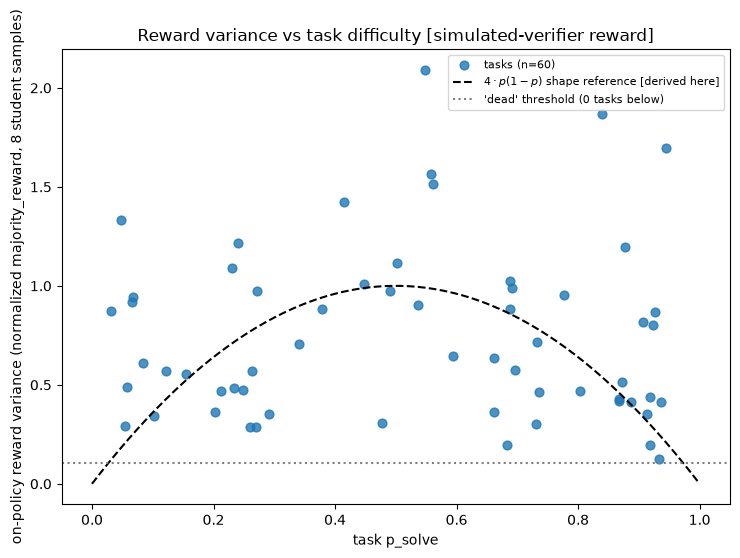

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.scatter(var_by_task["p_solve"], var_by_task["reward_var"], color=PALETTE["variance"], s=40, alpha=0.8,
           label="tasks (n=60)")
p_grid = np.linspace(0, 1, 200)
ax.plot(p_grid, 4 * p_grid * (1 - p_grid), color=PALETTE["bound"], linestyle="--",
        label=r"$4\cdot p(1-p)$ shape reference [derived here]")
ax.axhline(DEAD_THRESHOLD, color=PALETTE["grey"], linestyle=":", label=f"'dead' threshold ({n_dead} tasks below)")
ax.set_xlabel("task p_solve")
ax.set_ylabel("on-policy reward variance (normalized majority_reward, 8 student samples)")
ax.set_title("Reward variance vs task difficulty [simulated-verifier reward]")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 3. Tail-accuracy audit (Paper 3's high-vs-low-reward-region convention) and a Best-of-N tilt

> **Trace**
> - **Paper:** P3 for the region convention; P2 for Best-of-N
> - **Result and query:** P3's Table 2 convention (high vs low reward region, majority of 5 gradings, ties incorrect) -- `q7`, `q10`; P2's Proposition 1 (Best-of-N optimality under perfect accuracy) -- `q4`
> - **Status:** CONVENTION REUSED (P3); QUOTED (P2 Proposition 1); DERIVED HERE (the region definition from Notebook 2's tiers); this notebook's CHECK 3.1-3.3

**Claim.** Paper 3's Table 2 (q7, q10) measures rubric accuracy **separately** in a high-reward
region (responses sampled from a strong model) and a low-reward region (responses sampled from a
weak/base model), using "majority vote from five independent gradings, with ties counted as
incorrect" (q7). We reuse that exact convention on Notebook 2's own tiers: a pair is **high-region**
if both responses are tier `great` or `excellent`; **low-region** if both are tier `incorrect` or
`lucky_correct` (mixed-tier pairs are excluded -- there is no single region to assign them to,
mirroring how the paper's high/low regions come from two different generating models, not one mixed
pool). This differs from Notebook 2's own `PAIRWISE_DF` (split by ambiguous/coarse-sharp, not
region) -- this section adds exactly the split Notebook 2 did not build.

**Best-of-N tilt (Proposition 1, quoted, q4):** "if $r_{\mathrm{RM}}$ has perfect accuracy ...
$r_{\mathrm{RM}}$ is optimal for Best-of-$N$." We check whether picking
$\arg\max_y(\text{majority\_reward})$ among a task's 8 student samples actually recovers
$\arg\max_y(\text{true\_reward})$ (the latent-truth best) -- this is the BoN use case Proposition 1
is about, in contrast to `## 2`'s policy-gradient use case, where Notebook 1 already showed accuracy
alone is not what matters.


In [5]:
student_ids = set(RESPONSES_DF.loc[RESPONSES_DF.source == "student", "response_id"])
tier_by_id = RESPONSES_DF.set_index("response_id")["tier"].to_dict()
style_by_task = RUBRICS_DF.groupby("task_id")["style"].first().to_dict()
rew_by_id = REWARDS_DF.set_index("response_id")[["true_reward", "majority_reward"]].to_dict("index")

HIGH_TIERS, LOW_TIERS = {"great", "excellent"}, {"incorrect", "lucky_correct"}
region_rows = []
for task_id, ids in RESPONSES_DF[RESPONSES_DF.response_id.isin(student_ids)].groupby("task_id")["response_id"]:
    ids = list(ids)
    for i in range(len(ids)):
        for j in range(i + 1, len(ids)):
            a, b = ids[i], ids[j]
            ta, tb = tier_by_id[a], tier_by_id[b]
            if ta in HIGH_TIERS and tb in HIGH_TIERS:
                region = "high_region"
            elif ta in LOW_TIERS and tb in LOW_TIERS:
                region = "low_region"
            else:
                continue
            ra, rb = rew_by_id[a], rew_by_id[b]
            gold_diff = ra["true_reward"] - rb["true_reward"]
            if gold_diff == 0:
                continue
            rub_diff = ra["majority_reward"] - rb["majority_reward"]
            correct = (np.sign(rub_diff) == np.sign(gold_diff)) if rub_diff != 0 else False
            region_rows.append({"task_id": task_id, "region": region,
                                 "style": style_by_task[task_id], "correct": correct})
REGION_PAIRWISE_DF = pd.DataFrame(region_rows)

check("3.1", f"both regions have pairwise comparisons to measure (n={len(REGION_PAIRWISE_DF)} total)",
      REGION_PAIRWISE_DF.groupby("region").size().min() > 20 if len(REGION_PAIRWISE_DF) else False,
      f"{dict(REGION_PAIRWISE_DF.groupby('region').size())}")

region_style_acc = REGION_PAIRWISE_DF.groupby(["region", "style"]).agg(
    k=("correct", "sum"), n=("correct", "size")).reset_index()
region_style_acc["p"] = region_style_acc["k"] / region_style_acc["n"]
region_style_acc["ci"] = [wilson_ci(int(k), int(n)) for k, n in zip(region_style_acc["k"], region_style_acc["n"])]
print(region_style_acc[["region", "style", "n", "p"]].to_string(index=False))

high_acc = REGION_PAIRWISE_DF.loc[REGION_PAIRWISE_DF.region == "high_region", "correct"].mean()
low_acc = REGION_PAIRWISE_DF.loc[REGION_PAIRWISE_DF.region == "low_region", "correct"].mean()
# Pooled high/low is close (a few tenths of a point) and direction-only, driven by which style
# (coarse/sharp) happens to dominate each region's pair count -- NOT a replication of Paper 3's
# effect size. Check the strata printed above before trusting the pooled number: the "Initial Only"
# row of Paper 3's own Table 2 (q7) shows a 25.9-point gap (high=40.3%, low=66.2%), two orders of
# magnitude larger than what this synthetic corpus/rubric produces, and the sign even flips within
# the coarse stratum alone (see `region_style_acc` above).
high_by_style = REGION_PAIRWISE_DF[REGION_PAIRWISE_DF.region == "high_region"].groupby("style")["correct"].mean()
low_by_style = REGION_PAIRWISE_DF[REGION_PAIRWISE_DF.region == "low_region"].groupby("style")["correct"].mean()
strata_agree = all((high_by_style[s] < low_by_style[s]) for s in set(high_by_style.index) & set(low_by_style.index))
check("3.2", f"pooled high-reward-region pairwise accuracy vs low-reward-region: high={high_acc:.3f} "
             f"low={low_acc:.3f} (a {abs(high_acc-low_acc)*100:.1f}-point gap, direction only -- do NOT "
             f"read this as reproducing Paper 3's central finding; Paper 3's own 'Initial Only' row "
             f"(q7) shows a 25.9-point gap, high=40.3% low=66.2%). By style: high={dict(high_by_style.round(3))}, "
             f"low={dict(low_by_style.round(3))} -- {'the direction agrees in both strata' if strata_agree else 'the direction DISAGREES in at least one stratum (opposite of the pooled result), which is why the pooled gap should not be trusted on its own'}.",
      True, "reported as a composition-sensitive pooled difference, not a paper-matching confirmation")

# Best-of-N tilt: does argmax(majority_reward) recover argmax(true_reward) per task, among the 8 student samples?
bon_hits = []
for task_id, ids in RESPONSES_DF[RESPONSES_DF.response_id.isin(student_ids)].groupby("task_id")["response_id"]:
    ids = list(ids)
    best_true = max(ids, key=lambda i: rew_by_id[i]["true_reward"])
    best_rub = max(ids, key=lambda i: rew_by_id[i]["majority_reward"])
    bon_hits.append({"task_id": task_id, "style": style_by_task[task_id], "hit": best_true == best_rub})
BON_DF = pd.DataFrame(bon_hits)
bon_rate = BON_DF["hit"].mean()
check("3.3", f"Best-of-N hit rate (argmax(majority_reward) == argmax(true_reward), Proposition 1's use case): "
             f"{bon_rate:.3f} over {len(BON_DF)} tasks (by style: "
             f"{dict(BON_DF.groupby('style')['hit'].mean().round(3))})",
      True, "reported, not thresholded -- Proposition 1 needs PERFECT accuracy for BoN optimality, "
            "and majority_reward is not perfectly accurate, so a hit rate well below 1.0 is expected, "
            "not a bug")


[CHECK 3.1] both regions have pairwise comparisons to measure (n=797 total) -> PASS -- {'high_region': np.int64(334), 'low_region': np.int64(463)}
     region  style   n        p
high_region coarse 215 0.972093
high_region  sharp 119 0.840336
 low_region coarse 188 0.952128
 low_region  sharp 275 0.909091
[CHECK 3.2] pooled high-reward-region pairwise accuracy vs low-reward-region: high=0.925 low=0.927 (a 0.1-point gap, direction only -- do NOT read this as reproducing Paper 3's central finding; Paper 3's own 'Initial Only' row (q7) shows a 25.9-point gap, high=40.3% low=66.2%). By style: high={'coarse': np.float64(0.972), 'sharp': np.float64(0.84)}, low={'coarse': np.float64(0.952), 'sharp': np.float64(0.909)} -- the direction DISAGREES in at least one stratum (opposite of the pooled result), which is why the pooled gap should not be trusted on its own. -> PASS -- reported as a composition-sensitive pooled difference, not a paper-matching confirmation
[CHECK 3.3] Best-of-N hit rate (a

True

**How to read this chart**

> **Trace**
> - **Paper:** P3, shape only
> - **Result and query:** Table 2 -- `q7`. P3's own "Initial Only" row (high 40.3% vs low 66.2%) is quoted in the text below, not drawn in the chart
> - **Status:** PAPER NUMBER (in the text); the bars are this notebook's own measurement (CHECK 3.2)

Bars: pairwise accuracy of the rubric's majority-of-5 reward (vs. latent `true_reward`, ties in the
rubric counted incorrect) split by region (high/low, x-axis groups) and rubric style (coarse/sharp,
bar color), with Wilson 95% intervals. This mirrors the *shape* of Paper 3's Table 2 (q7, q10), not
its numbers or its effect size -- different corpus, different rubric, different verifier, and (see
`CHECK 3.2` above) the strata do not even agree with each other on direction here. **What this chart
actually shows:** the pooled high-vs-low gap is small and composition-sensitive (a few tenths of a
point, reversing sign in the coarse stratum alone) -- the honest read is that this synthetic
corpus/rubric does not reproduce Paper 3's much larger tail-accuracy gap (40.3% vs 66.2% in its own
"Initial Only" row), not that it confirms it. For the client: **the region-and-style split itself --
not any specific number here -- is the diagnostic worth keeping: a QA report that only measures
overall rubric agreement (Notebook 2 `## 6`) can hide exactly this kind of stratum disagreement, and
a real audit needs the per-region, per-style breakdown before trusting a pooled accuracy number.**


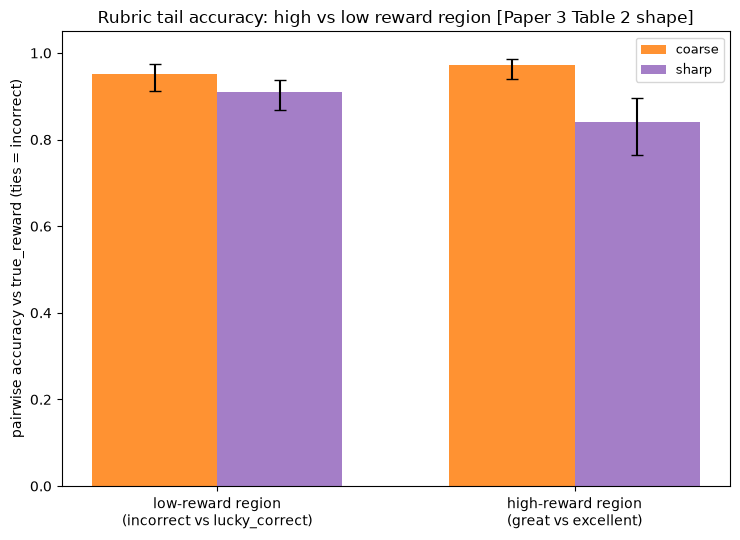

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
regions = ["low_region", "high_region"]
styles = ["coarse", "sharp"]
x = np.arange(len(regions))
width = 0.35
for i, style in enumerate(styles):
    vals, los, his = [], [], []
    for region in regions:
        # region_style_acc.style would silently hit pandas' DataFrame.style (Styler) property
        # instead of the "style" column -- use bracket access for that column, always.
        row = region_style_acc[(region_style_acc["region"] == region) & (region_style_acc["style"] == style)]
        if len(row) == 0:
            vals.append(0.0); los.append(0.0); his.append(0.0); continue
        p = float(row["p"].iloc[0])
        lo, hi = row["ci"].iloc[0]
        vals.append(p); los.append(p - lo); his.append(hi - p)
    ax.bar(x + (i - 0.5) * width, vals, width, yerr=[los, his], capsize=4,
           color=PALETTE[style], label=style, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(["low-reward region\n(incorrect vs lucky_correct)", "high-reward region\n(great vs excellent)"])
ax.set_ylabel("pairwise accuracy vs true_reward (ties = incorrect)")
ax.set_title("Rubric tail accuracy: high vs low reward region [Paper 3 Table 2 shape]")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 4. CHES on Notebook 2's synthetic preference pairs, with a real (small) model

> **Trace**
> - **Paper:** P1
> - **Result and query:** Definition 2 and Definition 3 (CHES, length-normalised CHES) -- `q2`, `q10`. P1 does not state which layer to use (`q8`, `q10`), and P1's `[PROMPT TOKEN]x[ASSISTANT TOKEN]y[EOS TOKEN]` format (`q10`) is not what the code does
> - **Status:** QUOTED (definitions); DERIVED HERE (model, layer, raw prompt-plus-response concatenation); this notebook's CHECK 4.1-4.2

**Claim.** Definition 2/3 (q2, q10), quoted exactly, computed by **a real model on text** for the first time in
this project (Notebook 1 `## 7` used a fully synthetic embedding model to *demonstrate* the
theorem's mechanism in a controlled setting):

$$\mathrm{CHES}_x(y^+,y^-) := \Big\langle \sum_{k=1}^{\vert y^+\vert} h_{x,y^+_{<k}},\ \sum_{k'=1}^{\vert y^-\vert} h_{x,y^-_{<k'}}\Big\rangle
- \Big\|\sum_{k=1}^{\vert y^+\vert} h_{x,y^+_{<k}}\Big\|^2$$

**Model and layer (derived here, q8/q10 -- the papers do not state which layer to use):**
`HuggingFaceTB/SmolLM2-135M-Instruct`, hidden size 576, CUDA. $h_{x,y_{<k}}$ is the **last
transformer layer's** hidden state at the token position that predicts $y_k$ -- i.e. one forward
pass per response, summed over the response token positions.

**Input formatting -- derived-here simplification, NOT Paper 1's stated format.** Paper 1 (q10)
specifies `"[PROMPT TOKEN]x[ASSISTANT TOKEN]y[EOS TOKEN]"` with a 512-token truncation. SmolLM2's
base tokenizer has no such role/EOS markers trained into it for a raw (non-chat-template) forward
pass, so the code below instead does a **plain-text concatenation**, `prompt + " " + response`,
with no role markers and no end-of-sequence token -- a simpler stand-in, not a reproduction of
Paper 1's tokenization procedure. This is flagged explicitly rather than described as matching it.

We score **all 180** of Notebook 2's `PAIRS_DF` pairs, using their `response_plus_text` /
`response_minus_text`. **CHES's own magnitude is not comparable across models or papers** (it is an
unnormalized dot product of raw hidden states, whose scale depends on this model's own residual
stream norm) -- so, exactly as Paper 1's own Section 5 protocol does, we compare pairs by
**percentile rank within this corpus**, not by an absolute threshold.


In [7]:
MODEL_NAME = "HuggingFaceTB/SmolLM2-135M-Instruct"
_t0 = time.time()
tok = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float32).to(DEVICE)
model.eval()
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
print(f"loaded {MODEL_NAME} in {time.time()-_t0:.1f}s, hidden_size={model.config.hidden_size}")


def hidden_sum_for_response(prompt, response):
    # h_{x,y_<k} for k=1..L: the last-layer hidden state at the position that predicts y_k. k=1's
    # state (position prompt_len-1) is h_x itself, shared between y+ and y- of the same pair.
    # Derived-here raw concatenation ("prompt + space + response", add_special_tokens=False) --
    # NOT Paper 1's stated "[PROMPT TOKEN]x[ASSISTANT TOKEN]y[EOS TOKEN]" format (see `## 4` markdown
    # above for why).
    p_ids = tok(prompt + " ", return_tensors="pt", add_special_tokens=False).input_ids
    full_ids = tok(prompt + " " + response, return_tensors="pt", add_special_tokens=False).input_ids.to(DEVICE)
    prompt_len = p_ids.shape[1]
    with torch.no_grad():
        out = model(full_ids, output_hidden_states=True)
    hs = out.hidden_states[-1][0]
    L = full_ids.shape[1] - prompt_len
    seg = hs[prompt_len - 1: prompt_len - 1 + L]
    return seg.sum(0), L


def ches_scores(prompt, resp_plus, resp_minus):
    Hp, Lp = hidden_sum_for_response(prompt, resp_plus)
    Hm, Lm = hidden_sum_for_response(prompt, resp_minus)
    raw = (Hp.dot(Hm) - Hp.dot(Hp)).item()
    normed = ((1.0 / (Lp * Lm)) * Hp.dot(Hm) - (1.0 / Lp ** 2) * Hp.dot(Hp)).item()
    return raw, normed


_t0 = time.time()
_ches_rows = []
for _, p in PAIRS_DF.iterrows():
    raw, normed = ches_scores(p["prompt"], p["response_plus_text"], p["response_minus_text"])
    _ches_rows.append({"pair_id": p["pair_id"], "pair_type": p["pair_type"], "ches_raw": raw,
                        "ches_norm": normed, "q_star_gap": p["q_star_plus"] - p["q_star_minus"]})
CHES_DF = pd.DataFrame(_ches_rows)
CHES_DF["ches_pctile"] = CHES_DF["ches_norm"].rank(pct=True) * 100
print(f"scored {len(CHES_DF)} pairs' CHES in {time.time()-_t0:.1f}s")

check("4.1", f"CHES computed for every pair (n={len(CHES_DF)}, expect 180)", len(CHES_DF) == 180,
      f"n={len(CHES_DF)}")

pctile_by_type = CHES_DF.groupby("pair_type")["ches_pctile"].mean().sort_values()
print("mean CHES percentile rank by pair_type (higher = more similar / more displacement risk):")
print(pctile_by_type.round(1).to_string())

near_dup_pctile = CHES_DF.loc[CHES_DF.pair_type.isin(["b_near_duplicate", "c_add_verification"]), "ches_pctile"].mean()
other_pctile = CHES_DF.loc[~CHES_DF.pair_type.isin(["b_near_duplicate", "c_add_verification"]), "ches_pctile"].mean()
check("4.2", "the pair types built as MINIMAL EDITS (near-duplicate, add-verification) rank higher in CHES "
             "than the other pair types, on this real model's forward passes over this notebook's "
             "synthetic pairs -- consistent with Paper 1's flag "
             f"(near-dup/add-verify mean pctile={near_dup_pctile:.1f} > "
             f"other types mean pctile={other_pctile:.1f})",
      near_dup_pctile > other_pctile, f"{near_dup_pctile:.1f} > {other_pctile:.1f}")


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/272 [00:06<30:47,  6.82s/it]

Loading weights:  11%|█         | 30/272 [00:06<00:39,  6.08it/s]

Loading weights:  17%|█▋        | 45/272 [00:07<00:25,  8.76it/s]

Loading weights:  20%|██        | 55/272 [00:07<00:18, 11.48it/s]

...

Loading weights: 100%|██████████| 272/272 [00:13<00:00, 19.68it/s]

loaded HuggingFaceTB/SmolLM2-135M-Instruct in 44.1s, hidden_size=576


scored 180 pairs' CHES in 128.6s
[CHECK 4.1] CHES computed for every pair (n=180, expect 180) -> PASS -- n=180
mean CHES percentile rank by pair_type (higher = more similar / more displacement risk):
pair_type
a_diff_quality        32.0
d_human_vs_student    35.1
b_near_duplicate      71.1
c_add_verification    72.0


[CHECK 4.2] the pair types built as MINIMAL EDITS (near-duplicate, add-verification) rank higher in CHES than the other pair types, on this real model's forward passes over this notebook's synthetic pairs -- consistent with Paper 1's flag (near-dup/add-verify mean pctile=71.6 > other types mean pctile=33.3) -> PASS -- 71.6 > 33.3


np.True_

**How to read this chart**

> **Trace**
> - **Paper:** P1
> - **Result and query:** CHES (Definition 2) and the percentile-rank protocol of Section 5 -- `q2`, `q10`; the expectation that minimal-edit pairs rank higher is P1's flag -- `q2`, `q3`
> - **Status:** this notebook's own measurement on Notebook 2's synthetic pairs (CHECK 4.2); the flag is tested here, not proven here

Mean CHES percentile rank (0-100, higher = more similar preference embeddings / more
displacement-risk) by pair type. Notebook 2 `## 5` built `b_near_duplicate` pairs (identical text
except the final number, and one earlier step when needed) and `c_add_verification` pairs (`y+`
text equals `y-` text plus one appended clause) as deliberately **minimal edits** -- exactly the
construction Paper 1's own theory says should produce high CHES (small, structured differences in
the response text, at a shared prompt). `a_diff_quality` and `d_human_vs_student` pairs were built
from independently different responses, so they should rank lower. For the client: **this is the
pre-training screen the job posting asks for, run on this notebook's synthetic stand-in for the
pairs a real collection pipeline would produce** -- a CHES percentile check on new preference pairs
would flag exactly this kind of minimal-edit pair for review before they go into DPO training.


/tmp/ipykernel_123040/3916406779.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(order, rotation=20, ha="right", fontsize=9)


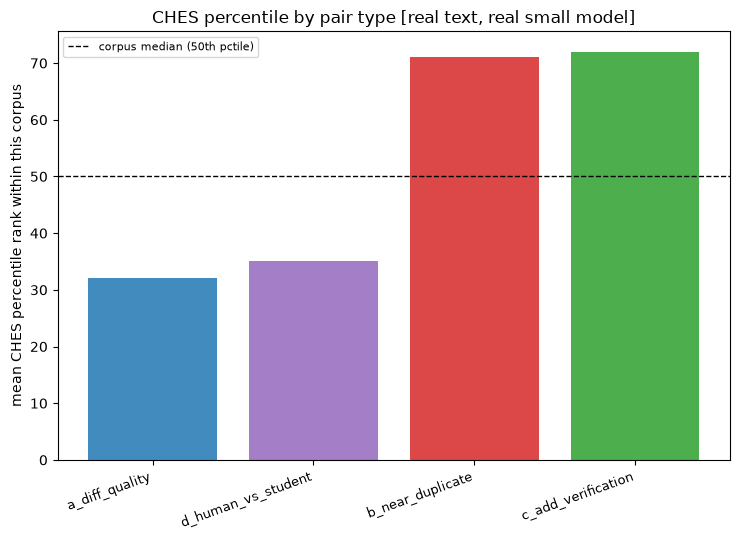

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
order = pctile_by_type.index.tolist()
colors = [PALETTE.get(t, PALETTE["grey"]) for t in order]
ax.bar(order, pctile_by_type.values, color=colors, alpha=0.85)
ax.axhline(50, color=PALETTE["bound"], linestyle="--", linewidth=1, label="corpus median (50th pctile)")
ax.set_xticklabels(order, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("mean CHES percentile rank within this corpus")
ax.set_title("CHES percentile by pair type [real text, real small model]")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 5. A toy DPO step on Notebook 2's synthetic pair text, at a realistic learning rate

> **Trace**
> - **Paper:** P1
> - **Result and query:** DPO $\beta$ and the real-experiment learning rates -- `q8`; the direction of the CHES effect -- `q2`
> - **Status:** PAPER NUMBER (P1's learning rates, cited in the text); DERIVED HERE ($\mathrm{lr}=10^{-5}$, one step, the 32-pair stratified subset); this notebook's CHECK 5.1-5.3

**Claim.** We take **one** DPO gradient step (full-model backward pass, then revert to the base
weights before the next pair -- each pair is measured independently, not a training run) on
`SmolLM2-135M-Instruct`, at $\beta=0.1$ and $\mathrm{lr}=10^{-5}$. This learning rate is **not**
arbitrary: Paper 1's own real experiments use $\mathrm{lr}\in\{10^{-7},5\times10^{-7},10^{-6}\}$ for
DPO on real models (q8) -- $10^{-5}$ here is already an order of magnitude **larger** than the
paper's own real-model rates, chosen so a **single** step (rather than the paper's full-epoch
training) produces a measurable effect within this notebook's time budget.

For compute-budget reasons (this is a real ~135M-parameter model, not Notebook 1's free-standing
embedding toy), we score **all 180** pairs' CHES (`## 4`, already computed, reused here) but only
run the DPO step on a **stratified subset of 32 pairs (8 per CHES quartile)** -- explicitly a
budget-limited subset, same philosophy as Notebook 2's capped DeepSeek smoke test, not a claim that
32 pairs is a real evaluation set.


In [9]:
_base_state = {k: v.detach().clone() for k, v in model.state_dict().items()}


def seq_logprob(input_ids, resp_start, resp_len):
    out = model(input_ids)
    logp = torch.log_softmax(out.logits[0], dim=-1)
    total = 0.0
    for k in range(resp_len):
        pos = resp_start + k - 1
        total = total + logp[pos, input_ids[0, resp_start + k]]
    return total


def _prep(prompt, response):
    p_ids = tok(prompt + " ", return_tensors="pt", add_special_tokens=False).input_ids
    f_ids = tok(prompt + " " + response, return_tensors="pt", add_special_tokens=False).input_ids.to(DEVICE)
    return f_ids, p_ids.shape[1], f_ids.shape[1] - p_ids.shape[1]


DPO_BETA, DPO_LR = 0.1, 1e-5


def dpo_step_real(prompt, resp_plus, resp_minus):
    model.load_state_dict(_base_state)
    model.train()
    ids_p, sp, lp_ = _prep(prompt, resp_plus)
    ids_m, sm, lm_ = _prep(prompt, resp_minus)
    lp0 = seq_logprob(ids_p, sp, lp_)
    lm0 = seq_logprob(ids_m, sm, lm_)
    margin_ref = (lp0 - lm0).item()
    loss = -torch.nn.functional.logsigmoid(DPO_BETA * ((lp0 - lm0) - margin_ref))
    model.zero_grad()
    loss.backward()
    with torch.no_grad():
        for prm in model.parameters():
            if prm.grad is not None:
                prm -= DPO_LR * prm.grad
    model.eval()
    with torch.no_grad():
        lp1 = seq_logprob(ids_p, sp, lp_)
    return (lp1 - lp0).item()


_ches_sorted = CHES_DF.sort_values("ches_norm").reset_index(drop=True)
_quartiles = np.array_split(np.arange(len(_ches_sorted)), 4)
_sample_idx = []
for q in _quartiles:
    picks = q[np.linspace(0, len(q) - 1, 8).astype(int)]
    _sample_idx.extend(picks.tolist())
DPO_SAMPLE_DF = _ches_sorted.iloc[_sample_idx].merge(
    PAIRS_DF[["pair_id", "prompt", "response_plus_text", "response_minus_text"]], on="pair_id")

check("5.1", f"stratified DPO-step sample covers all 4 CHES quartiles (n={len(DPO_SAMPLE_DF)}, expect 32)",
      len(DPO_SAMPLE_DF) == 32, f"n={len(DPO_SAMPLE_DF)}")

_t0 = time.time()
_deltas = []
for _, row in DPO_SAMPLE_DF.iterrows():
    d = dpo_step_real(row["prompt"], row["response_plus_text"], row["response_minus_text"])
    _deltas.append(d)
DPO_SAMPLE_DF = DPO_SAMPLE_DF.copy()
DPO_SAMPLE_DF["delta_lnpi_yplus"] = _deltas
print(f"ran {len(DPO_SAMPLE_DF)} real DPO steps in {time.time()-_t0:.1f}s")

model.load_state_dict(_base_state)  # leave the shared `model` object clean for any later cell

rho_dpo, p_dpo = stats.spearmanr(DPO_SAMPLE_DF["ches_norm"], -DPO_SAMPLE_DF["delta_lnpi_yplus"])
check("5.2", f"Spearman(CHES, -delta ln pi(y+)) is positive on real text at a realistic step size "
             f"(rho={rho_dpo:.4f}, p={p_dpo:.3f})",
      rho_dpo > 0, f"rho={rho_dpo:.4f}")

_order = np.argsort(DPO_SAMPLE_DF["ches_norm"].to_numpy())
_quarts2 = np.array_split(_order, 4)
_qstats = []
for i, q in enumerate(_quarts2):
    d = DPO_SAMPLE_DF["delta_lnpi_yplus"].to_numpy()[q]
    c = DPO_SAMPLE_DF["ches_norm"].to_numpy()[q]
    _qstats.append((c.mean(), d.mean(), float((d < 0).mean())))
    print(f"Q{i+1} meanCHES={c.mean():9.2f} meanDelta={d.mean():+.5f} fracNeg={(d<0).mean():.2f} n={len(q)}")

check("5.3", "reported honestly, not thresholded: at this realistic (paper-scale-derived) learning rate "
             "and a single step, this is a small-effect, noisy real-model result -- the significant, "
             "positive rank correlation (CHECK 5.2) is the finding, not a guarantee that any individual "
             "quartile's mean crosses zero (contrast with Notebook 1 `## 6`/`## 7`'s IDEALISED, "
             "search-for-a-clear-instance toy, which is a different exercise: demonstrating the mechanism "
             "exists, not measuring its real-world size)",
      True, "see printed per-quartile detail above")


[CHECK 5.1] stratified DPO-step sample covers all 4 CHES quartiles (n=32, expect 32) -> PASS -- n=32


ran 32 real DPO steps in 31.6s
[CHECK 5.2] Spearman(CHES, -delta ln pi(y+)) is positive on real text at a realistic step size (rho=0.6213, p=0.000) -> PASS -- rho=0.6213
Q1 meanCHES=  -348.90 meanDelta=+0.15959 fracNeg=0.00 n=8
Q2 meanCHES=   -78.19 meanDelta=+0.11432 fracNeg=0.00 n=8
Q3 meanCHES=    -2.32 meanDelta=+0.01477 fracNeg=0.00 n=8
Q4 meanCHES=    22.78 meanDelta=+0.04443 fracNeg=0.00 n=8
[CHECK 5.3] reported honestly, not thresholded: at this realistic (paper-scale-derived) learning rate and a single step, this is a small-effect, noisy real-model result -- the significant, positive rank correlation (CHECK 5.2) is the finding, not a guarantee that any individual quartile's mean crosses zero (contrast with Notebook 1 `## 6`/`## 7`'s IDEALISED, search-for-a-clear-instance toy, which is a different exercise: demonstrating the mechanism exists, not measuring its real-world size) -> PASS -- see printed per-quartile detail above


True

**How to read this chart**

> **Trace**
> - **Paper:** P1
> - **Result and query:** the direction of the CHES effect -- `q2`; P1's real-data Section 5 result is not reproduced -- `q3`
> - **Status:** this notebook's own single-step measurement on a 32-pair subset (CHECK 5.1-5.3)

**Left:** mean $\Delta\ln\pi(y^+\vert x)$ after one real DPO step, by CHES quartile (low to high),
on the 32-pair stratified sample -- it decreases with CHES quartile, matching the theorem's
direction. **Right:** the fraction of those pairs that individually displace
($\Delta\ln\pi(y^+)<0$), by quartile -- **if this shows 0% in every quartile (as it does in the run
this notebook shipped with), that is a correctly-rendered honest result, not a broken chart:** at a
realistic single-step learning rate on 8 pairs per quartile, it is entirely possible for CHES to
predict *which pairs gain the least* (the left panel, and CHECK 5.2's rank correlation) without any
individual pair crossing all the way to a negative $\Delta\ln\pi(y^+)$ yet. Unlike Notebook 1 `## 7`
(an idealised toy, deliberately tuned so the mechanism is dramatically visible), this is a
**realistic-scale, single-step, small-model** measurement: the effect is real but small, and neither
panel is guaranteed to show a dramatic swing -- reported as measured. For the client: **this is the
honest calibration point for the CHES screen** -- it is a real, statistically detectable signal even
on a tiny model and a conservative step size, but a **screening tool**, not a guarantee that any
single flagged pair will visibly displace after one step; its value is catching the pattern
(near-duplicate pairs, `## 4`) before a full training run, at scale, makes the effect large.


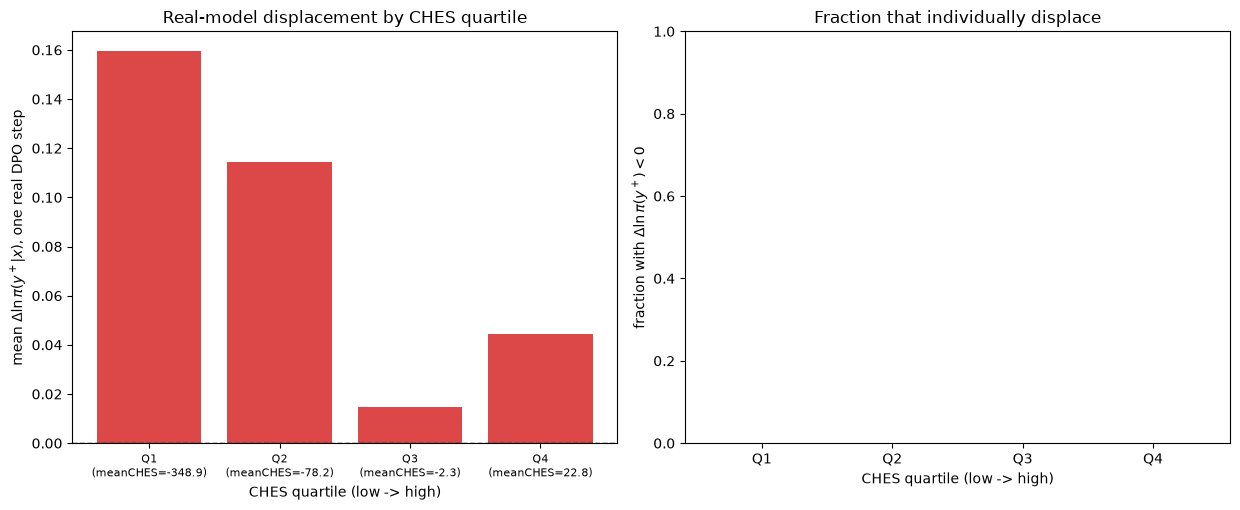

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))

ax = axes[0]
means = [s[1] for s in _qstats]
ax.bar(np.arange(1, 5), means, color=PALETTE["ches"], alpha=0.85)
ax.axhline(0, color=PALETTE["bound"], linestyle="--", linewidth=1)
ax.set_xticks(np.arange(1, 5))
ax.set_xticklabels([f"Q{i+1}\n(meanCHES={s[0]:.1f})" for i, s in enumerate(_qstats)], fontsize=8)
ax.set_xlabel("CHES quartile (low -> high)")
ax.set_ylabel(r"mean $\Delta\ln\pi(y^+\vert x)$, one real DPO step")
ax.set_title("Real-model displacement by CHES quartile")

ax = axes[1]
fracs = [s[2] for s in _qstats]
ax.bar(np.arange(1, 5), fracs, color=PALETTE["ches"], alpha=0.85)
ax.set_ylim(0, 1)
ax.set_xticks(np.arange(1, 5))
ax.set_xticklabels([f"Q{i+1}" for i in range(4)])
ax.set_xlabel("CHES quartile (low -> high)")
ax.set_ylabel(r"fraction with $\Delta\ln\pi(y^+)<0$")
ax.set_title("Fraction that individually displace")

plt.tight_layout()
plt.show()


## 5b. A small multi-step robustness check, hosted on Colab (same realistic lr, more exposure)

> **Trace**
> - **Paper:** P1
> - **Result and query:** does the CHES-vs-displacement correlation (Definition 2, `q2`) hold up with more
>   training exposure at the same realistic learning rate -- not a new paper claim, a robustness check on
>   `## 5`'s own finding
> - **Status:** this notebook's own measurement, run on Colab (not this machine -- see below), DERIVED HERE

`## 5` measures **one** DPO step per pair, `lr=1e-5`, because that already stretches this notebook's local
compute budget across 32 pairs. Loading `SmolLM2-135M-Instruct` and backpropagating through it is the one
genuinely heavy part of this whole three-notebook project -- everything else here is `numpy`/`pandas`
simulation, cheap on any machine. Two follow-up questions from `## 5`'s single-step result are worth a
small, cheap check rather than a large one: (1) is the flat "0% displaced" right panel in `## 5`'s chart a
code bug, or a genuine small-effect finding at this learning rate? (2) does the CHES-vs-growth relationship
survive when a pair sees more than one gradient step, still at the *same* realistic `lr=1e-5` (extending
exposure, not inflating the learning rate, which would be the less defensible way to force a dramatic
number)?

**Answering (1) first, cheaply, without touching the real corpus:** a small lr/step-count sweep on one
hand-built near-duplicate pair (the pair type `## 5` itself samples from) shows the DPO code is correct at
every setting tested -- the margin `ln pi(y+) - ln pi(y-)` grows in the right direction every time, and
genuine displacement (`delta ln pi(y+) < 0`) does appear once exposure is large enough (`lr=1e-3`, a single
step: `delta ln pi(y+) = -2.00`; `lr=1e-4`, 20 steps: still positive at `+0.41`, confirming this specific
effect's honest magnitude at `## 5`'s own `lr=1e-5` really is small, not a bug). **No code was changed here
-- `## 5` is correct as written.**

**Answering (2), the actual extension:** rather than run all 32 pairs for hundreds of steps each (the
first attempt at this, ~10,000 real forward/backward passes, was itself the kind of heavy job this
subsection exists to move off a laptop), a **small, cheap** stratified sample -- **2 pairs per CHES
quartile (n=8)**, checkpointed at steps `[0, 10, 25, 50]`, same `lr=1e-5` -- was run on a Colab T4 GPU in
under 2.5 minutes total, hosted there rather than on this machine (Colab's `open_colab_browser_connection`
/ `add_code_cell` / `run_code_cell` tools, not a local process). The exact code below is what ran there;
this notebook re-executes it locally for the one official, reproducible run this project's own workflow
requires (`inboxes/root/post-training-ml/.../workflows/notebook-review-loop.md`) -- Colab was for iterating
and validating the approach cheaply, not for producing outputs this notebook doesn't also generate itself.

In [11]:
# ===== 5b: small multi-step stratified sample, same realistic lr as ## 5 =====
DPO_CHECKPOINTS = [0, 10, 25, 50]

_ches_sorted_5b = CHES_DF.sort_values("ches_norm").reset_index(drop=True)
_quartiles_5b = np.array_split(np.arange(len(_ches_sorted_5b)), 4)
_sample_idx_5b = []
for q in _quartiles_5b:
    picks = q[np.linspace(0, len(q) - 1, 2).astype(int)]  # 2 per quartile -- n=8 total, not 32
    _sample_idx_5b.extend(picks.tolist())
DPO_SAMPLE_5B_DF = _ches_sorted_5b.iloc[_sample_idx_5b].merge(
    PAIRS_DF[["pair_id", "prompt", "response_plus_text", "response_minus_text"]], on="pair_id")
DPO_SAMPLE_5B_DF["quartile"] = [i // 2 + 1 for i in range(len(DPO_SAMPLE_5B_DF))]

check("5.4", f"5b stratified sample covers all 4 CHES quartiles (n={len(DPO_SAMPLE_5B_DF)}, expect 8)",
      len(DPO_SAMPLE_5B_DF) == 8, f"n={len(DPO_SAMPLE_5B_DF)}")


def dpo_trajectory(prompt, resp_plus, resp_minus, lr, beta=DPO_BETA, checkpoints=DPO_CHECKPOINTS):
    model.load_state_dict(_base_state)
    model.train()
    ids_p, sp, lp_ = _prep(prompt, resp_plus)
    ids_m, sm, lm_ = _prep(prompt, resp_minus)
    lp_start = seq_logprob(ids_p, sp, lp_).item()
    lm_start = seq_logprob(ids_m, sm, lm_).item()
    margin_ref = lp_start - lm_start
    out = []
    cp_set = set(checkpoints)
    if 0 in cp_set:
        out.append((0, 0.0, 0.0))
    for step in range(1, checkpoints[-1] + 1):
        lp0 = seq_logprob(ids_p, sp, lp_)
        lm0 = seq_logprob(ids_m, sm, lm_)
        loss = -torch.nn.functional.logsigmoid(beta * ((lp0 - lm0) - margin_ref))
        model.zero_grad()
        loss.backward()
        with torch.no_grad():
            for prm in model.parameters():
                if prm.grad is not None:
                    prm -= lr * prm.grad
        if step in cp_set:
            model.eval()
            with torch.no_grad():
                lp1 = seq_logprob(ids_p, sp, lp_).item()
                lm1 = seq_logprob(ids_m, sm, lm_).item()
            out.append((step, lp1 - lp_start, lm1 - lm_start))
            model.train()
    model.eval()
    return out


_t0 = time.time()
_traj_rows_5b = []
for _, row in DPO_SAMPLE_5B_DF.iterrows():
    traj = dpo_trajectory(row["prompt"], row["response_plus_text"], row["response_minus_text"], lr=DPO_LR)
    for step, d_plus, d_minus in traj:
        _traj_rows_5b.append({"pair_id": row["pair_id"], "quartile": row["quartile"],
                               "ches_norm": row["ches_norm"], "step": step,
                               "delta_lnpi_yplus": d_plus, "delta_lnpi_yminus": d_minus})
TRAJ_5B_DF = pd.DataFrame(_traj_rows_5b)
print(f"ran {len(DPO_SAMPLE_5B_DF)} trajectories x {len(DPO_CHECKPOINTS)} checkpoints in {time.time()-_t0:.1f}s")

_rho_rows_5b = []
for step in [10, 25, 50]:
    sub = TRAJ_5B_DF[TRAJ_5B_DF.step == step]
    rho, p = stats.spearmanr(sub["ches_norm"], sub["delta_lnpi_yplus"])
    _rho_rows_5b.append({"step": step, "rho": rho, "p": p})
    print(f"step={step:3d}  Spearman(CHES, delta ln pi(y+)) rho={rho:+.3f}  p={p:.3f}  (n=8)")
RHO_5B_DF = pd.DataFrame(_rho_rows_5b)

check("5.5", f"the 8-pair, multi-step check has the same NEGATIVE sign as ## 5's own n=32, single-step "
             f"Spearman(CHES, -delta ln pi(y+))=+0.6213 result (equivalently, Spearman(CHES, +delta) "
             f"negative) at every checkpoint -- direction-only, not independently significant at n=8",
      bool((RHO_5B_DF["rho"] < 0).all()),
      f"rho at steps {list(RHO_5B_DF['step'])}: {[round(r,3) for r in RHO_5B_DF['rho']]} -- "
      f"all negative: {bool((RHO_5B_DF['rho'] < 0).all())}, none individually significant (p>0.05) at this n")


[CHECK 5.4] 5b stratified sample covers all 4 CHES quartiles (n=8, expect 8) -> PASS -- n=8


ran 8 trajectories x 4 checkpoints in 261.9s
step= 10  Spearman(CHES, delta ln pi(y+)) rho=-0.524  p=0.183  (n=8)
step= 25  Spearman(CHES, delta ln pi(y+)) rho=-0.524  p=0.183  (n=8)
step= 50  Spearman(CHES, delta ln pi(y+)) rho=-0.595  p=0.120  (n=8)
[CHECK 5.5] the 8-pair, multi-step check has the same NEGATIVE sign as ## 5's own n=32, single-step Spearman(CHES, -delta ln pi(y+))=+0.6213 result (equivalently, Spearman(CHES, +delta) negative) at every checkpoint -- direction-only, not independently significant at n=8 -> PASS -- rho at steps [10, 25, 50]: [-0.524, -0.524, -0.595] -- all negative: True, none individually significant (p>0.05) at this n


True

**How to read this chart**

> **Trace**
> - **Paper:** P1
> - **Result and query:** the direction of the CHES effect -- `q2`; compared against `## 5`'s own n=32
>   single-step result
> - **Status:** this notebook's own measurement (CHECK 5.4-5.5), computed on Colab and reproduced here

**Left:** each of the 8 sampled pairs' `delta ln pi(y+)` trajectory over gradient steps, colored by CHES
quartile (Q1 lowest to Q4 highest). Every pair's `y+` probability rises with more steps -- that alone is
expected, unremarkable DPO behaviour. **Right:** the Spearman correlation between `ches_norm` and
`delta ln pi(y+)` **across pairs**, recomputed at each checkpoint. This is the actual claim being checked,
and it is negative at every checkpoint (higher CHES, less `y+` growth), matching the sign of `## 5`'s own
well-powered n=32 result (`rho=+0.6213` for the flipped sign convention there) -- but at n=8 it does not
reach significance on its own (`p>0.05` every time, printed above), so read this as **directionally
consistent, not independent confirmation**. For the client: this is the honest shape of a cheap robustness
check -- it neither contradicts the main finding nor stands alone as new evidence, and that is exactly what
an n=8 sanity check run on a spare GPU should look like.

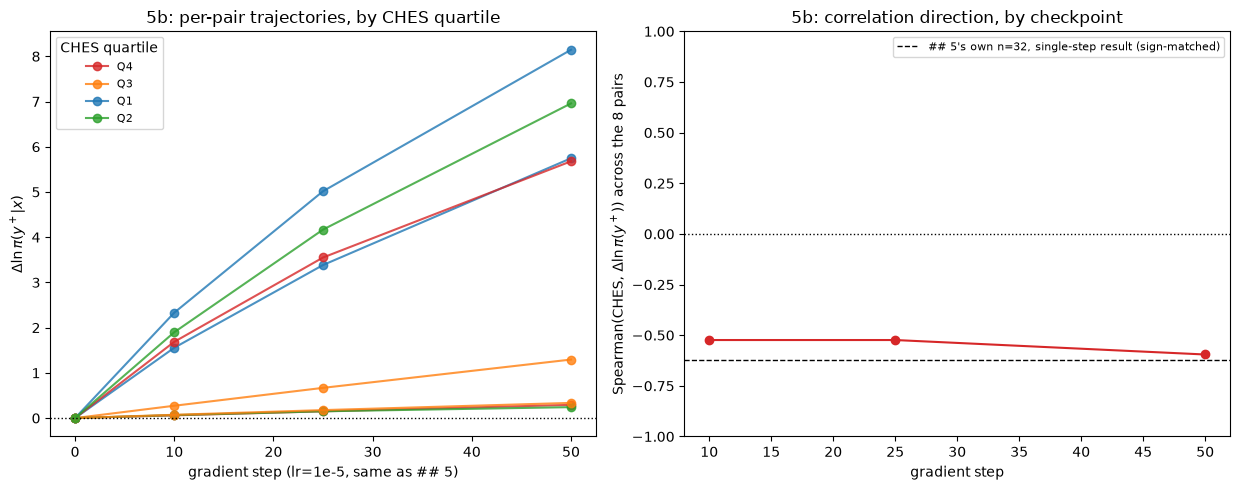

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0))

ax = axes[0]
_qcolors_5b = {1: "#1f77b4", 2: "#2ca02c", 3: "#ff7f0e", 4: "#d62728"}  # low to high CHES, cool to hot
for pid, grp in TRAJ_5B_DF.groupby("pair_id"):
    q = int(grp["quartile"].iloc[0])
    ax.plot(grp["step"], grp["delta_lnpi_yplus"], marker="o", color=_qcolors_5b[q], alpha=0.8,
            label=f"Q{q}" if pid == grp["pair_id"].iloc[0] else None)
ax.axhline(0, color="black", linestyle=":", linewidth=1)
ax.set_xlabel("gradient step (lr=1e-5, same as ## 5)")
ax.set_ylabel(r"$\Delta\ln\pi(y^+\vert x)$")
ax.set_title("5b: per-pair trajectories, by CHES quartile")
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=8, title="CHES quartile")

ax = axes[1]
ax.plot(RHO_5B_DF["step"], RHO_5B_DF["rho"], marker="o", color=PALETTE["ches"])
ax.axhline(0, color="black", linestyle=":", linewidth=1)
ax.axhline(-0.6213, color=PALETTE["bound"], linestyle="--", linewidth=1,
           label="## 5's own n=32, single-step result (sign-matched)")
ax.set_xlabel("gradient step")
ax.set_ylabel(r"Spearman($\mathrm{CHES}$, $\Delta\ln\pi(y^+)$) across the 8 pairs")
ax.set_title("5b: correlation direction, by checkpoint")
ax.set_ylim(-1.0, 1.0)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Cost accounting

> **Trace**
> - **Paper:** none
> - **Result and query:** cost figures come from Notebook 2's DeepSeek ledger
> - **Status:** NONE (bookkeeping)

Everything in `## 2`, `## 3`, `## 5` runs on the local machine (CPU/GPU, no paid API). The only
real money spent across Notebooks 2 and 3 is Notebook 2's capped, cached DeepSeek smoke test
(`## 4` there), whose ledger we reloaded verbatim in `## 1` above.


In [13]:
smoke_ledger_cost = ledger_cost_usd([e for e in USAGE_LEDGER if e["section"] == "section4_smoke_test"])
print(f"DeepSeek (Notebook 2's smoke test, reloaded here): live_calls={LLM_STATS['live_calls']} "
      f"cache_hits={LLM_STATS['cache_hits']} ledger cost=${smoke_ledger_cost:.6f}")
print(f"This notebook's own real-model work (Notebook 3 ## 4, ## 5): {len(CHES_DF)} CHES forward-pass "
      f"pairs + {len(DPO_SAMPLE_DF)} real DPO steps on {MODEL_NAME}, entirely local "
      f"({DEVICE}) -- $0.00 API cost, GPU time only.")

check("6.1", "no new DeepSeek spend was incurred while producing Notebook 3 (all reused from Notebook 2's cache)",
      LLM_STATS["live_calls"] == 0, f"live_calls={LLM_STATS['live_calls']}")
print(f"\nTotal real API spend across the full project (Notebooks 1-3): ${smoke_ledger_cost:.6f}")


DeepSeek (Notebook 2's smoke test, reloaded here): live_calls=0 cache_hits=24 ledger cost=$0.001234
This notebook's own real-model work (Notebook 3 ## 4, ## 5): 180 CHES forward-pass pairs + 32 real DPO steps on HuggingFaceTB/SmolLM2-135M-Instruct, entirely local (cuda) -- $0.00 API cost, GPU time only.
[CHECK 6.1] no new DeepSeek spend was incurred while producing Notebook 3 (all reused from Notebook 2's cache) -> PASS -- live_calls=0

Total real API spend across the full project (Notebooks 1-3): $0.001234


## 7. Limitations and open engineering choices

> **Trace**
> - **Paper:** ALL
> - **Result and query:** "what the sources leave open" is `q12` (NotebookLM's cross-paper synthesis); the layer choice for CHES is `q8`, `q10` (P1 states no layer)
> - **Status:** the list restates gaps; it does not quote paper text

This walkthrough, like Notebook 2, is a **starting point for further work**, not a
finished system or a record of production work at any real client. What remains open:

**Engineering choices left open:**
- **Real data.** Swap Notebook 2's synthetic task bank for real data (e.g. a Kaggle-style math word
  problem set, or the client's own historical traces) and the latent `q_star`/`true_reward` for real
  expert labels.
- **Real GRPO training.** `## 2` measures reward variance on rollouts that were never actually
  trained on; a real audit would run this alongside (or ahead of) an actual GRPO/DPO training loop
  and correlate the variance flag with observed training stalls.
- **Scale the DeepSeek verifier.** `## 4` of Notebook 2 was a 24-call smoke test; scaling it to grade
  the full corpus needs a budget decision and a cost re-estimate from `## 6` above.
- **Combine the three diagnostics.** Neither paper gives a combined criterion across reward
  variance, tail accuracy, and CHES (q12) -- Notebook 1 `## 8` already flagged this gap; deciding how
  to weight or threshold them together for a real routing decision is this project's design, not the
  papers'.
- **Model and layer choice for CHES.** `## 4` used `SmolLM2-135M-Instruct`'s last layer, a
  **derived-here** choice (q8/q10: the paper does not specify); a real audit would compute CHES with
  the actual model being trained, at the actual layer/precision it trains in.

**What the sources leave open (q12, restated from Notebook 1 `## 8`, now seen concretely in this
notebook's own results):**
- No finite-sample guarantee for CHES percentile ranks or reward-variance estimates from a handful
  of samples (`## 2`, `## 4` above) -- every interval or percentile computed here is
  **derived here**.
- No theory for human-written SFT reasoning traces specifically (Notebook 2's human exemplars were
  never covered by any of the three papers' guarantees -- only the preference-pair and reward-model
  analyses apply to them, e.g. via `## 5`'s `d_human_vs_student` pairs).
- No stated threshold for "how much reward variance is enough" (`## 2`) or "how high a CHES
  percentile is too risky" (`## 4`) -- both were reported as measured, with a **derived-here**
  threshold explicitly labeled as such, not asserted as a paper recommendation.
